In [1]:
import os
repo = 'boston-marathons'
counter = 0
max_depth = 50
current = os.getcwd()
while True:
    current_tmp = os.path.basename(os.getcwd())
    if current_tmp == repo:
        print(f"Main dir found: {os.getcwd()}")
        break
    else:
        os.chdir("..")
        counter += 1
        if counter >= max_depth:
            print(f"Reached {max_depth} levels up — '{repo}' not found.")
            os.chdir(current)
            print(f"Current path: {current}")
            break

Main dir found: D:\Scripts\Data Science\projekty\repo\boston-marathons


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math as math
from scripts.mappings import continent_colors

In [5]:
df = pd.read_csv('./data/clean/boston_features.csv')
df.head()

,Name,M/F,Age,Age Group,Country,Continent,City,Pace,5K,10K,15K,20K,25K,30K,35K,40K,Official Time,Year,Place_Year,Place_Global
0,"Desisa, Lelisa",M,25,22–25,ETH,Africa,Ambo,3.065431,0.245278,0.495278,0.749167,1.008056,1.268611,1.533333,1.799722,2.044167,2.154722,2015,1,1
1,"Kirui, Geoffrey",M,24,22–25,KEN,Africa,Keringet,3.075787,0.256944,0.507778,0.762222,1.020833,1.283056,1.550278,1.805278,2.048056,2.160278,2017,1,2
2,"Tsegay, Yemane Adhane",M,30,30–33,ETH,Africa,Addis Ababa,3.086144,0.245278,0.495278,0.749444,1.007778,1.268611,1.533056,1.799722,2.045000,2.163333,2015,2,3
3,"Rupp, Galen",M,30,30–33,USA,North America,Portland,3.086144,0.256667,0.507500,0.762222,1.020833,1.283056,1.550278,1.805278,2.053889,2.166111,2017,2,4
4,"Chebet, Wilson",M,29,26–29,KEN,Africa,Marakwet,3.096500,0.245278,0.495278,0.749167,1.008056,1.268611,1.533333,1.799722,2.050278,2.172778,2015,3,5


In [7]:
plt.style.use('seaborn-v0_8-whitegrid')

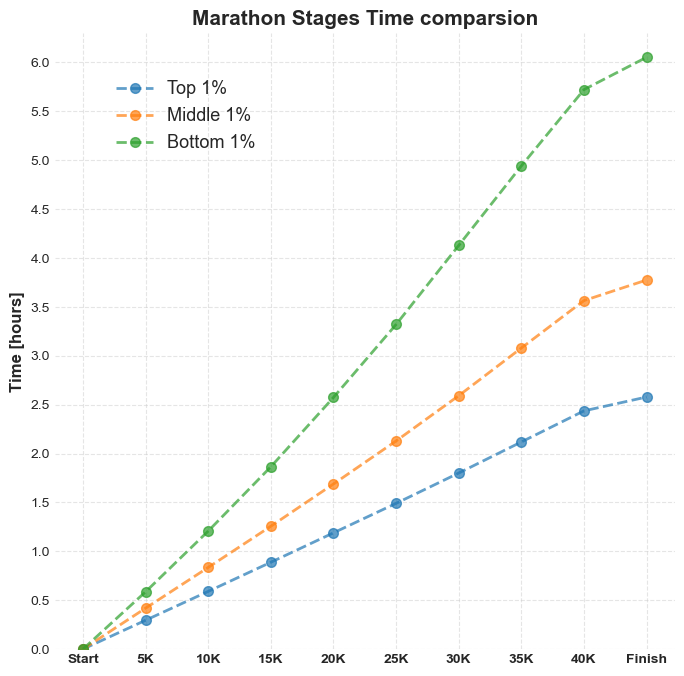

In [306]:
# fig
fig, ax = plt.subplots(figsize=(8,8))
# subsets
df['Start'] = 0 # start stage
subset_top = df.iloc[:int(len(df)*.01)]
subset_mid = df.iloc[int(len(df)*.495):int(len(df)*.505)]
subset_bot = df.iloc[int(len(df)*.99):]
subsets = [subset_top, subset_mid, subset_bot]
labels = ['Top 1%', 'Middle 1%', 'Bottom 1%']
# xy variables
xstages = ['Start', '5K','10K','15K','20K','25K','30K','35K','40K','Finish']
ystages = xstages.copy()
ystages[-1] = 'Official Time'
# create plot
for subset, label in zip(subsets, labels):
    x = xstages
    y = subset[ystages].mean()
    ax.plot(x, y, 'o--', linewidth=2, markersize=7, alpha=.7, label=label)
## xy settings
# x
for tick in ax.xaxis.get_major_ticks():
    tick.label1.set_fontweight('bold')
# y
ax.set_ylabel('Time [hours]', weight='bold', fontsize=12)
ax.set_ylim(0,6.3)
ax.set_yticks(np.arange(0,6.1,.5))

# style
ax.set_title('Marathon Stages Time comparsion', weight='bold', fontsize=15)
ax.grid(True, linestyle='--', alpha=.5)
ax.legend(fontsize=13, bbox_to_anchor=(.35,.95))
ax.spines[['top','bottom','left','right']].set_visible(False)

# plt.savefig('test/chart_15.png', dpi=300, bbox_inches='tight')
plt.show()